# ParkVest LSTM notebook for multi-step fall prediction

This notebook builds a **sequence model (LSTM)** that uses the patient's visit history to predict whether the **first fall event** happens in the next `HORIZON` visits.

The notebook is designed to match the same data structure and logic as your Cox notebook:

- `BL_CASE` is used as the patient ID
- controls are filtered out if the ID contains `"K"`
- visit dates are read from `V{v}_DateVisit`
- a fall event is defined as the first visit where:
  - `UPO13 >= 1`, or
  - `UPO14 >= 3`
- features are built from visit-level data and **event-defining columns are excluded** to avoid leakage

Along the way, CSV files and figures are saved to make it easier to inspect what is happening.

## 1. Imports and configuration

Adjust in particular:

- `DATA_PATH`
- `VISIT_START` / `VISIT_END`
- `HORIZON`
- `LOOKBACK` (default `3`)
- `MIN_HISTORY_VISITS` (default `3`)
- `BASE_FEATURES`

`LOOKBACK=None` can still be used for full expanding history, but the default is a fixed window for more consistent samples.

In [34]:

import os
import random
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Feature and run configuration ----
FEATURE_SET = "feature_setB"  # feature set name (used in output path)
N_FEATURES = 30  # manually set number of features in current run

# ---- Paths ----
DATA_PATH = "../../Data/ParkVest_ClinicalData.csv"

# ---- ID + visits ----
ID_COL = "BL_CASE"
VISIT_START = 4
VISIT_END = 21
VISITS = list(range(VISIT_START, VISIT_END + 1))
DATE_COL_TEMPLATE = "V{v}_DateVisit"

# ---- Sequence task ----
HORIZON = 3                 # predict next HORIZON visits
LOOKBACK = 3                # fixed window (latest LOOKBACK visits)
MIN_HISTORY_VISITS = 3      # require at least this many visits in input
STOP_AFTER_FIRST_EVENT = False


BASE_FEATURES = [
    # Motorikk
    "PIGD",
    "UPO_part2_tot",
    "UPO_part3_tot",
    "UPO27",
    "UPO15",
    "UPO_part4_tot",
    # Kognisjon
    "STROOPW",
    "MMSE_tot",
    "IQCODE_mean",
    "STROOPC",
    "MCI_15SD_MDScriteria",
    # Stemning/psykiatri
    "madrs10",
    "madrs_tot",
    "npi8hi",
    # Søvn
    "pdss02",
    "pdss_tot",
    "epwo6",
    # Autonome symptomer
    "URINDYS",
    "CONSTIPAT",
    "PressStand_Dia",
    "SEON",
    # Tretthet/apati
    "fss2",
    "fss_sum",
    "fss5",
    # Livskvalitet
    "sf36pf",
    "sf36pcs",
    "PHYFUN",
    # Demografi/tid
    "age_at_visit",
    "disease_duration_years",
    "HYON",
]
# Exclude "disease_duration_years" from Delta features
DELTA_FEATURE_BASES = BASE_FEATURES.copy()


# ---- Training ----
BATCH_SIZE = 16
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.1
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 55
PATIENCE = 5
EVAL_THRESHOLD = 0.5

# ---- Generate unique run name and output directory ----
RUN_NAME = f"top{N_FEATURES}_H{HORIZON}_L{LOOKBACK}_HS{HIDDEN_SIZE}_BS{BATCH_SIZE}_E{EPOCHS}_P{PATIENCE}_N{NUM_LAYERS}_D{int(DROPOUT*100)}"
OUTPUT_DIR = Path(f"../../Results/LSTM/{FEATURE_SET}/results/{RUN_NAME}")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Run name: {RUN_NAME}")
print(f"Output directory: {OUTPUT_DIR}")

# Optional mild regularization to test quickly:
# NUM_LAYERS = 2
# DROPOUT = 0.2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Run name: top30_H3_L3_HS64_BS16_E55_P5_N1_D10
Output directory: ../../Results/LSTM/feature_setB/results/top30_H3_L3_HS64_BS16_E55_P5_N1_D10
Device: cpu


## 2. Load raw data

This is the same start as in the Cox setup: read the CSV, remove duplicate column names if needed, and verify that the ID column exists.

In [35]:

df = pd.read_csv(DATA_PATH)

dup_cols = df.columns[df.columns.duplicated()].tolist()
if dup_cols:
    print("Duplicate columns found. Keeping first occurrence:", dup_cols)
    df = df.loc[:, ~df.columns.duplicated()].copy()

if ID_COL not in df.columns:
    candidates = [c for c in df.columns if c.lower() in ("id", "patient_id", "patientid", "subject", "subject_id")]
    if not candidates:
        raise ValueError(f"ID_COL='{ID_COL}' not found and no obvious alternative.")
    ID_COL = candidates[0]
    print("Detected ID column:", ID_COL)

print("Shape:", df.shape)
print("ID column:", ID_COL)
display(df.head(2))

/var/folders/95/t78xg19j37g0pzlmfynn1p280000gn/T/ipykernel_1890/2645424504.py:1: DtypeWarning: Columns (6,10,11,17,20,39,41,42,46,85,100,139,140,141,142,143,147,148,149,151,152,187,530,789,807,817,930,957,1312,1525,1526,1543,1553,1665,1711,1721,1852,1853,1899,1912,2041,2042,2048,2049,2114,2138,2527,2758,2801,2803,2805,2807,2808,2819,2940,2941,2944,2949,2952,2962,2965,2968,2971,2973,2986,2988,2990,2992,3002,3008,3010,3026,3147,3148,3192,3194,3196,3198,3209,3333,3405,3413,3429,3453,3456,3565,3598,3601,3602,3604,3606,3850,4039,4040,4085,4087,4089,4091,4105,4113,4115,4134,4220,4243,4268,4272,4316,4318,4320,4322,4336,4343,4344,4360,4362,4384,4387,4473,4496,4520,4565,4567,4569,4571,4585,4593,4595,4614,4700,4723,4813,4826,4850,4852,4987,5023,5024,5026,5028,5425,5428,5432,5433,5434,5435,5439,5440,5441,5442,5446,5447,5448,5449,5453,5454,5455,5456,5460,5461,5462,5463,5467,5468,5469,5470,5472,5473,5474,5475,5476,5477,5479,5480,5482,5483,5484,5487,5488,5489,5490,5491,5492,5493,5494,5496,5497,5498,

Shape: (417, 7187)
ID column: BL_CASE


,BL_CASE,Status290719,Included290719,Status290719num,MORSdate_220219,DATscan,DATscan_date,Hjerneobduksjon,Hjernedonasjoner_mottat041017,inkl_flønes,...,V21_TEF,V21_PPHC,V21_MMHC,V21_GGHC,V21_PHC,V21_MHC,V21_GHC,V21_TPHC,V21_TMHC,V21_TGHC
0,A01,Fortsatt i studien,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,60.0,60.1256,72.1832,75.1868,60.0,72.0,75.0,50.0,61.0,65.0
1,A02,Dropout etter V16 (død),1.0,1.0,2011-05-28,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Remove controls

Same logic as in the Cox notebook: IDs that contain `"K"` are treated as controls and removed.

In [36]:

df0 = df.copy()
df0[ID_COL] = df0[ID_COL].astype(str)
df0 = df0[~df0[ID_COL].str.contains("K", na=False)].copy()

print("After dropping controls:", df0.shape)
display(df0[[ID_COL]].head(10))

After dropping controls: (212, 7187)


,BL_CASE
0,A01
1,A02
2,A03
3,A06
4,A07
5,A08
6,A09
7,A10
8,A11
9,A12


## 4. Repair and standardize visit dates

We use the same `DateVisit` logic as in the Cox notebook:

- dates are read from `V4_DateVisit` ... `V21_DateVisit`
- unreasonable years or non-increasing dates are marked as bad
- if a date is bad and the previous date exists, it is replaced with `previous + 6 months`

This is useful both for feature engineering and for ensuring the correct chronological order.

SPSS conversion: patient A01, visit V15, raw=13508121600.0 → converted=2010-11-03
SPSS conversion: patient A01, visit V16, raw=13525056000.0 → converted=2011-05-18
SPSS conversion: patient A01, visit V18, raw=13560739200.0 → converted=2012-07-04
SPSS conversion: patient A01, visit V19, raw=13571020800.0 → converted=2012-10-31
SPSS conversion: patient A01, visit V20, raw=13584931200.0 → converted=2013-04-10
SPSS conversion: patient A02, visit V15, raw=13508121600.0 → converted=2010-11-03
SPSS conversion: patient A02, visit V16, raw=13525228800.0 → converted=2011-05-20
SPSS conversion: patient A03, visit V15, raw=13508726400.0 → converted=2010-11-10
SPSS conversion: patient A03, visit V16, raw=13524451200.0 → converted=2011-05-11
SPSS conversion: patient A03, visit V18, raw=13558492800.0 → converted=2012-06-08
SPSS conversion: patient A03, visit V19, raw=13571020800.0 → converted=2012-10-31
SPSS conversion: patient A03, visit V20, raw=13584931200.0 → converted=2013-04-10
SPSS conversion:

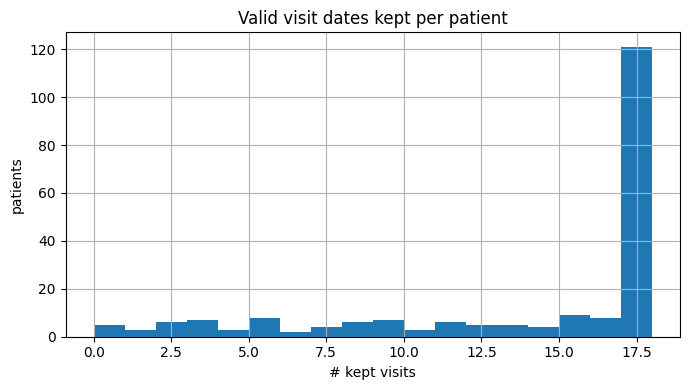

,BL_CASE,V4_DateVisit,V5_DateVisit,V6_DateVisit,V7_DateVisit,V8_DateVisit,V9_DateVisit,V10_DateVisit,V11_DateVisit,V12_DateVisit,V13_DateVisit,V14_DateVisit,V15_DateVisit,V16_DateVisit,V17_DateVisit,V18_DateVisit,V19_DateVisit,V20_DateVisit,V21_DateVisit
0,A01,2005-04-26,2005-11-28,2006-05-09,2006-11-23,2007-05-16,2007-11-27,2008-06-04,2008-11-03,2009-05-26,2009-11-18,2010-05-26,2010-11-03,2011-05-18,2012-01-17,2012-07-04,2012-10-31,2013-04-10,2013-10-30
1,A02,2005-05-12,2005-11-29,2006-05-09,2006-11-15,2007-06-26,2007-11-29,NaT,2008-10-30,2009-05-26,2009-11-18,2010-06-02,2010-11-03,2011-05-20,NaT,NaT,NaT,NaT,NaT
2,A03,2005-05-23,2005-11-30,2006-05-10,2006-11-15,2007-05-09,2007-11-29,2008-06-12,2008-11-04,2009-05-28,2009-11-18,2010-05-26,2010-11-10,2011-05-11,2012-01-16,2012-06-08,2012-10-31,2013-04-10,2013-10-30
3,A06,2005-08-18,2006-02-23,2006-08-10,2007-02-12,2007-08-27,2008-01-04,2008-10-07,2009-01-20,2009-08-26,2010-01-13,2010-09-01,2011-02-02,2011-11-16,2012-04-10,2012-10-31,2013-04-03,2013-09-27,2014-02-12
4,A07,2005-06-30,2005-12-13,2006-06-23,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


In [37]:
date_cols = [DATE_COL_TEMPLATE.format(v=v) for v in VISITS]

missing_date_cols = [c for c in date_cols if c not in df0.columns]
if missing_date_cols:
    raise ValueError(
        f"Missing expected date columns (showing up to 10): {missing_date_cols[:10]}\n"
        f"Found date-like columns: {[c for c in df0.columns if 'date' in c.lower()][:30]}"
    )

dates = df0[[ID_COL] + date_cols].copy()

# Counters and logs
total_slots = 0
count_valid_original = 0
count_converted_spss = 0
count_skipped_missing = 0
count_skipped_unresolvable = 0
count_skipped_unreasonable_spss = 0
count_skipped_date_order = 0
pids_with_dropped_visits = set()
individual_logs = []

SPSS_EPOCH = pd.Timestamp("1582-10-14")
REASONABLE_MIN = pd.Timestamp("1990-01-01")
REASONABLE_MAX = pd.Timestamp("2030-12-31")


def is_numeric_scalar(raw):
    return isinstance(raw, (int, float, np.integer, np.floating)) and not isinstance(raw, (bool, np.bool_))


def is_datetime_scalar(raw):
    return isinstance(raw, (pd.Timestamp, np.datetime64))


def try_parse_date(raw, pid, v):
    if pd.isna(raw) or (isinstance(raw, str) and raw.strip() == ""):
        return None, "missing", None

    if is_datetime_scalar(raw):
        parsed = pd.Timestamp(raw)
        if pd.isna(parsed):
            return None, "missing", None
        return parsed, "datetime", None

    numeric_value = None
    if is_numeric_scalar(raw):
        numeric_value = float(raw)
    elif isinstance(raw, str):
        raw_strip = raw.strip()
        try:
            numeric_value = float(raw_strip)
        except Exception:
            numeric_value = None

    if numeric_value is not None:
        try:
            # Numeric SPSS values are treated as seconds from the SPSS epoch.
            converted = pd.Timestamp(SPSS_EPOCH.to_pydatetime() + timedelta(seconds=float(numeric_value)))
        except Exception:
            msg = (
                f"SPSS conversion produced unreasonable date: patient {pid}, visit V{v}, "
                f"raw={raw} → converted=overflow, skipped."
            )
            individual_logs.append(msg)
            print(msg)
            return None, "unreasonable_spss", None

        if (converted < REASONABLE_MIN) or (converted > REASONABLE_MAX):
            msg = (
                f"SPSS conversion produced unreasonable date: patient {pid}, visit V{v}, "
                f"raw={raw} → converted={converted}, skipped."
            )
            individual_logs.append(msg)
            print(msg)
            return None, "unreasonable_spss", converted

        return converted, "spss", converted

    parsed = pd.to_datetime(raw, errors="coerce")
    if pd.isna(parsed):
        msg = f"Unresolvable date: patient {pid}, visit V{v}, raw value={raw}"
        individual_logs.append(msg)
        print(msg)
        return None, "unresolvable", None

    parsed = pd.Timestamp(parsed)
    return parsed, "datetime", None


rows = []
patients_processed = 0

for _, r in dates.iterrows():
    pid = str(r[ID_COL])
    patients_processed += 1
    row_out = {ID_COL: pid}

    parsed_dates = {}
    visit_status = {}
    patient_had_drop = False

    for v in VISITS:
        total_slots += 1
        c = DATE_COL_TEMPLATE.format(v=v)
        raw = r[c]

        parsed, status, converted_date = try_parse_date(raw, pid, v)

        if status == "missing":
            count_skipped_missing += 1
            parsed_dates[v] = None
            visit_status[v] = "missing"
            patient_had_drop = True
            pids_with_dropped_visits.add(pid)
            continue

        if status == "unresolvable":
            count_skipped_unresolvable += 1
            pids_with_dropped_visits.add(pid)
            patient_had_drop = True
            parsed_dates[v] = None
            visit_status[v] = "unresolvable"
            continue

        if status == "unreasonable_spss":
            count_skipped_unreasonable_spss += 1
            pids_with_dropped_visits.add(pid)
            patient_had_drop = True
            parsed_dates[v] = None
            visit_status[v] = "unreasonable_spss"
            continue

        if status == "spss":
            count_converted_spss += 1
            msg = f"SPSS conversion: patient {pid}, visit V{v}, raw={raw} → converted={parsed.date()}"
            individual_logs.append(msg)
            print(msg)
        else:
            count_valid_original += 1

        parsed_dates[v] = parsed
        visit_status[v] = status

    prev_date = None
    prev_visit = None
    for v in VISITS:
        d = parsed_dates.get(v)
        if d is None:
            continue

        if prev_date is None:
            prev_date = d
            prev_visit = v
            continue

        if not (d > prev_date):
            count_skipped_date_order += 1
            pids_with_dropped_visits.add(pid)
            patient_had_drop = True
            msg = (
                f"Date order violation: patient {pid}, visit V{v} date={d.date()} "
                f"is not after V{prev_visit} date={prev_date.date()}"
            )
            individual_logs.append(msg)
            print(msg)
            parsed_dates[v] = None
            visit_status[v] = "date_order"
            continue

        prev_date = d
        prev_visit = v

    for v in VISITS:
        c = DATE_COL_TEMPLATE.format(v=v)
        d = parsed_dates.get(v)
        row_out[c] = pd.NaT if d is None else d

    rows.append(row_out)

repaired = pd.DataFrame(rows)

# Summary calculations
total_kept = int(repaired.drop(columns=[ID_COL]).notna().sum().sum())
total_dropped = total_slots - total_kept

print("=== Date repair summary ===")
print(f"Total visit slots processed: {total_slots}")
print(f"  - Valid original dates:     {count_valid_original}")
print(f"  - Converted from SPSS:      {count_converted_spss}")
print(f"  - Skipped (missing/NaN):    {count_skipped_missing}")
print(f"  - Skipped (unresolvable):   {count_skipped_unresolvable}")
print(f"  - Skipped (date order):     {count_skipped_date_order}")
print(f"  - Skipped (unreasonable SPSS): {count_skipped_unreasonable_spss}")
print(f"Total visit rows kept:        {total_kept}")
print(f"Total visit rows dropped:     {total_dropped}")
print(f"Patients affected by drops:   {len(pids_with_dropped_visits)}")
patients_with_drops = len(set(pids_with_dropped_visits))
print(f"Patients with at least one dropped visit: {patients_with_drops}")

repaired.to_csv(OUTPUT_DIR / "visit_dates_repaired.csv", index=False)

plt.figure(figsize=(7, 4))
repaired_count_per_patient = repaired.drop(columns=[ID_COL]).notna().sum(axis=1)
repaired_count_per_patient.hist(bins=range(0, max(2, len(VISITS) + 1)))
plt.title("Valid visit dates kept per patient")
plt.xlabel("# kept visits")
plt.ylabel("patients")
plt.tight_layout()
plt.show()

display(repaired.head())

In [38]:
# Check which patients have a V21 date and whether they have drops
v21_col = DATE_COL_TEMPLATE.format(v=21)
has_v21 = repaired[repaired[v21_col].notna()][ID_COL].tolist()
has_v21_with_drops = [p for p in has_v21 if p in pids_with_dropped_visits]

print(f"Pasienter med gyldig V21: {len(has_v21)}")
print(f"Av disse har drops på andre visits: {len(has_v21_with_drops)}")

# Check whether any V15/V16 drops still have V21
repaired_melted = repaired.melt(id_vars=[ID_COL], var_name='visit_col', value_name='date')
repaired_melted = repaired_melted[repaired_melted['date'].isna()]
v15_drops = repaired_melted[repaired_melted['visit_col'] == DATE_COL_TEMPLATE.format(v=15)][ID_COL].tolist()
both = [p for p in v15_drops if p in has_v21]
print(f"Pasienter med droppet V15 men gyldig V21: {len(both)}")
print("Eksempler:", both[:5])

Pasienter med gyldig V21: 126
Av disse har drops på andre visits: 22
Pasienter med droppet V15 men gyldig V21: 1
Eksempler: ['H07']


## 5. Find the event visit for the first fall

We use the same event definition as in the Cox notebook:

- the first visit where `UPO13 >= 1`
- or the first visit where `UPO14 >= 3`

We automatically select the best available column variant per visit, for example:

- `V{v}_UPO13`
- `V{v}_UPO13_ON`
- `V{v}_UPO13_OFF`
- `V{v}_UPO13_1`

And the same for `UPO14`.

In [39]:

def pick_best_measure(df_in: pd.DataFrame, base: str, v: int):
    candidates = [
        f"V{v}_{base}",
        f"V{v}_{base}_ON",
        f"V{v}_{base}_OFF",
        f"V{v}_{base}_1",
    ]
    candidates = [c for c in candidates if c in df_in.columns]
    if not candidates:
        return None
    miss = {c: df_in[c].isna().mean() for c in candidates}
    return sorted(miss.items(), key=lambda x: x[1])[0][0]

upo13_cols = {v: pick_best_measure(df0, "UPO13", v) for v in VISITS}
upo14_cols = {v: pick_best_measure(df0, "UPO14", v) for v in VISITS}

print("UPO13 mapping:", upo13_cols)
print("UPO14 mapping:", upo14_cols)

# def first_event_visit(row: pd.Series):
#     for v in VISITS:
#         c13 = upo13_cols[v]
#         c14 = upo14_cols[v]
#         if (c13 is None) or (c14 is None):
#             continue
#         x13 = row[c13]
#         x14 = row[c14]
#         if pd.notna(x13) and (x13 >= 1):
#             return v, 1
#         if pd.notna(x14) and (x14 >= 3):
#             return v, 1
#     return None, 0

# evt = df0.apply(lambda r: pd.Series(first_event_visit(r), index=["event_visit", "event"]), axis=1)

# pat = df0[[ID_COL]].copy()
# pat[ID_COL] = pat[ID_COL].astype(str)
# pat["event_visit"] = evt["event_visit"]
# pat["event"] = evt["event"].astype(int)

def has_any_event(row: pd.Series):
    for v in VISITS:
        c13 = upo13_cols[v]
        c14 = upo14_cols[v]
        if (c13 is None) or (c14 is None):
            continue
        if pd.notna(row[c13]) and row[c13] >= 1:
            return 1
        if pd.notna(row[c14]) and row[c14] >= 3:
            return 1
    return 0

pat = df0[[ID_COL]].copy()
pat[ID_COL] = pat[ID_COL].astype(str)
pat["event"] = df0.apply(has_any_event, axis=1)
pat["event_visit"] = np.nan  # ikke lenger relevant

pat.to_csv(OUTPUT_DIR / "patient_event_summary.csv", index=False)

print("Event counts:", pat["event"].value_counts(dropna=False).to_dict())
display(pat.head(10))

# Count how many patient have UPO >= 13 once, and how many have UPO >= 14 once, to verify they are not identical:
upo13_any = df0.apply(lambda r: any((pd.notna(r[upo13_cols[v]]) and r[upo13_cols[v]] >= 1) for v in VISITS), axis=1)
upo14_any = df0.apply(lambda r: any((pd.notna(r[upo14_cols[v]]) and r[upo14_cols[v]] >= 3) for v in VISITS), axis=1)
print("Patients with UPO13 event:", int(upo13_any.sum()), "/", len(upo13_any))
print("Patients with UPO14 event:", int(upo14_any.sum()), "/", len(upo14_any))


UPO13 mapping: {4: 'V4_UPO13', 5: 'V5_UPO13', 6: 'V6_UPO13', 7: 'V7_UPO13', 8: 'V8_UPO13', 9: 'V9_UPO13_ON', 10: 'V10_UPO13_ON', 11: 'V11_UPO13_ON', 12: 'V12_UPO13_ON', 13: 'V13_UPO13_ON', 14: 'V14_UPO13_ON', 15: 'V15_UPO13_ON', 16: 'V16_UPO13_ON', 17: 'V17_UPO13_ON', 18: 'V18_UPO13_ON', 19: 'V19_UPO13_ON', 20: 'V20_UPO13_ON', 21: 'V21_UPO13_ON'}
UPO14 mapping: {4: 'V4_UPO14', 5: 'V5_UPO14', 6: 'V6_UPO14', 7: 'V7_UPO14', 8: 'V8_UPO14', 9: 'V9_UPO14_ON', 10: 'V10_UPO14_ON', 11: 'V11_UPO14_ON', 12: 'V12_UPO14_ON', 13: 'V13_UPO14_ON', 14: 'V14_UPO14_ON', 15: 'V15_UPO14_ON', 16: 'V16_UPO14_ON', 17: 'V17_UPO14_ON', 18: 'V18_UPO14_ON', 19: 'V19_UPO14_ON', 20: 'V20_UPO14_ON', 21: 'V21_UPO14_ON'}
Event counts: {1: 156, 0: 56}


,BL_CASE,event,event_visit
0,A01,1,NaN
1,A02,1,NaN
2,A03,0,NaN
3,A06,1,NaN
4,A07,0,NaN
5,A08,1,NaN
6,A09,0,NaN
7,A10,1,NaN
8,A11,1,NaN
9,A12,1,NaN


Patients with UPO13 event: 155 / 212
Patients with UPO14 event: 44 / 212


In [40]:
# Create a csv file with only BL_CASE, UPO13 and UPO14 columns for all visits, plus the event summary
features = []
for v in VISITS:
    c13 = upo13_cols[v]
    c14 = upo14_cols[v]
    if c13 is not None:
        features.append(c13)
    if c14 is not None:
        features.append(c14)

# remove duplicates while preserving order
features = list(dict.fromkeys(features))

event_summary = pat[[ID_COL, "event_visit", "event"]].copy()
df_with_events = df0.merge(event_summary, on=ID_COL, how="left")

cols_to_save = [ID_COL] + features + ["event_visit", "event"]
df_to_save = df_with_events[cols_to_save].copy()
df_to_save.to_csv(OUTPUT_DIR / "features_and_events.csv", index=False)

## 6. Build visit-level long format for LSTM

In the Cox notebook you built **intervals** (`start`, `stop`, `event`) between visits.  
For LSTM we instead need **one row per patient per visit**.

So here we do the following:

- use visit `v` as one time point in the sequence
- features are pulled from columns with prefix `V{v}_`
- `visit_date`, `time_since_anchor_years`, `disease_duration_years`, and `age_at_visit` are created explicitly
- `event_here = 1` only at the visit where the first fall occurs
- visits **after** the first event are dropped if `STOP_AFTER_FIRST_EVENT=True`

In [41]:

rep_map = repaired.set_index(ID_COL)
pat_map = pat.set_index(ID_COL)[["event", "event_visit"]]

def years_since_anchor(d: pd.Timestamp, anchor: pd.Timestamp) -> float:
    return float((d - anchor).days) / 365.25

def visit_feature_cols(df_in: pd.DataFrame, v: int):
    prefix = f"V{v}_"
    cols = [c for c in df_in.columns if c.startswith(prefix)]
    cols = [c for c in cols if "DateVisit" not in c]
    rm = {upo13_cols.get(v), upo14_cols.get(v)}
    cols = [c for c in cols if c not in rm]
    return cols

rows = []
dropped_no_anchor = 0
dropped_no_date = 0

for _, r in df0.iterrows():
    pid = str(r[ID_COL])

    if pid not in rep_map.index or pid not in pat_map.index:
        continue

    ev_flag = int(pat_map.loc[pid, "event"])
    ev_visit = pat_map.loc[pid, "event_visit"]

    d_list = [rep_map.loc[pid, DATE_COL_TEMPLATE.format(v=v)] for v in VISITS]
    d_list = [d for d in d_list if not pd.isna(d)]
    if not d_list:
        dropped_no_anchor += 1
        continue

    anchor = min(d_list)
    bl_age = r["BL_Age"] if "BL_Age" in df0.columns else np.nan

    for v in VISITS:
        d = rep_map.loc[pid, DATE_COL_TEMPLATE.format(v=v)]
        if pd.isna(d):
            dropped_no_date += 1
            continue

        if STOP_AFTER_FIRST_EVENT and ev_flag == 1 and pd.notna(ev_visit) and v > ev_visit:
            break

        # Check UPO13/UPO14 directly for this specific visit
        c13 = upo13_cols.get(v)
        c14 = upo14_cols.get(v)
        fall_here = 0
        if c13 is not None and pd.notna(r[c13]) and r[c13] >= 1:
            fall_here = 1
        if c14 is not None and pd.notna(r[c14]) and r[c14] >= 3:
            fall_here = 1

        disease_duration_years = years_since_anchor(d, anchor)

        row = {
            ID_COL: pid,
            "visit": int(v),
            "visit_date": d,
            "disease_duration_years": disease_duration_years,
            "event_here": fall_here,
            "event_any": int(ev_flag),
            "event_visit": ev_visit if pd.notna(ev_visit) else np.nan,
        }

        if pd.notna(bl_age):
            row["age_at_visit"] = float(bl_age) + disease_duration_years
        else:
            row["age_at_visit"] = np.nan

        feat_cols = visit_feature_cols(df0, v)
        prefix = f"V{v}_"
        for c in feat_cols:
            base = c[len(prefix):] if c.startswith(prefix) else c
            row[base] = r[c]

        rows.append(row)

long_df = pd.DataFrame(rows).sort_values([ID_COL, "visit"]).reset_index(drop=True)
long_df.to_csv(OUTPUT_DIR / "visit_level_long_raw.csv", index=False)

print("Long df shape:", long_df.shape)
print("Dropped patients (no anchor):", dropped_no_anchor)
print("Dropped visit rows (missing date):", dropped_no_date)
display(long_df.head())

Long df shape: (2940, 1214)
Dropped patients (no anchor): 5
Dropped visit rows (missing date): 786


,BL_CASE,visit,visit_date,disease_duration_years,event_here,event_any,event_visit,age_at_visit,DropOut,ReasonDropOut,...,QUIP_Informant,sleep_informant,rls_informant,epwo_informant,pdss_informant,SWLS.1,SWLS.2,SWLS.3,SWLS.4,SWLS.5
0,A01,4,2005-04-26,0.000000,0,1,NaN,65.306849,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A01,5,2005-11-28,0.591376,0,1,NaN,65.898225,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A01,6,2006-05-09,1.034908,0,1,NaN,66.341757,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A01,7,2006-11-23,1.577002,0,1,NaN,66.883851,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A01,8,2007-05-16,2.053388,0,1,NaN,67.360237,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Find patients without an anchor date
no_anchor_pids = []

for _, r in df0.iterrows():
    pid = str(r[ID_COL])
    
    if pid not in rep_map.index:
        continue
    
    d_list = [rep_map.loc[pid, DATE_COL_TEMPLATE.format(v=v)] for v in VISITS]
    d_list = [d for d in d_list if not pd.isna(d)]
    
    if not d_list:
        no_anchor_pids.append(pid)

print(f"Pasienter uten anchor date ({len(no_anchor_pids)}):")
for pid in no_anchor_pids:
    print(f"  {pid}")

Pasienter uten anchor date (5):
  B066
  B067
  B106
  H01
  H16


## 7. Simple check of visit data

This section saves a few summaries of visits per patient and where the first event occurs.

,n_visits
count,207.000000
mean,14.202899
std,5.332388
min,1.000000
25%,11.000000
50%,18.000000
75%,18.000000
max,18.000000


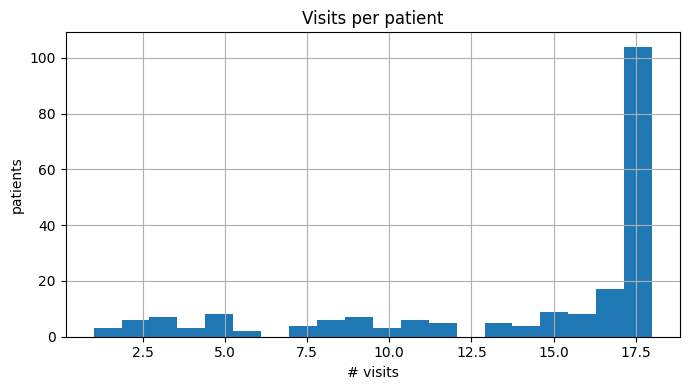

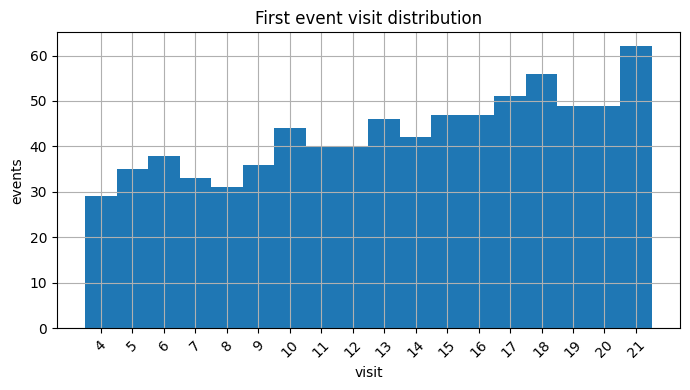

,BL_CASE,visit,visit_date,disease_duration_years,event_here,event_any,event_visit,age_at_visit,DropOut,ReasonDropOut,...,QUIP_Informant,sleep_informant,rls_informant,epwo_informant,pdss_informant,SWLS.1,SWLS.2,SWLS.3,SWLS.4,SWLS.5
8,A01,12,2009-05-26,4.082136,1,1,NaN,69.388985,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,A02,11,2008-10-30,3.468857,1,1,NaN,74.194884,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,A02,13,2009-11-18,4.520192,1,1,NaN,75.246219,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,A02,14,2010-06-02,5.056810,1,1,NaN,75.782838,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,A02,15,2010-11-03,5.478439,1,1,NaN,76.204467,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:

visit_counts = long_df.groupby(ID_COL).size().rename("n_visits").reset_index()
visit_counts.to_csv(OUTPUT_DIR / "visit_counts.csv", index=False)

event_rows = long_df[long_df["event_here"] == 1].copy()
event_rows[[ID_COL, "visit", "disease_duration_years"]].to_csv(
    OUTPUT_DIR / "event_visit_rows.csv", index=False
)

display(visit_counts.describe())

plt.figure(figsize=(7, 4))
visit_counts["n_visits"].hist(bins=20)
plt.title("Visits per patient")
plt.xlabel("# visits")
plt.ylabel("patients")
plt.tight_layout()
plt.show()

if len(event_rows) > 0:
    plt.figure(figsize=(7, 4))
    event_rows["visit"].hist(bins=np.arange(VISIT_START, VISIT_END + 2) - 0.5)
    plt.title("First event visit distribution")
    plt.xlabel("visit")
    plt.ylabel("events")
    plt.xticks(VISITS, rotation=45)
    plt.tight_layout()
    plt.show()

display(event_rows.head())

## 8. Select features

We intentionally start simple:

- clinically relevant features first
- exclude event-defining columns
- use only numeric features

You can expand `BASE_FEATURES` and `OPTIONAL_FEATURES` later.

In [44]:

candidate_features = BASE_FEATURES 
available_features = [c for c in candidate_features if c in long_df.columns]
missing_features = [c for c in candidate_features if c not in long_df.columns]

print("Available features:", available_features)
print("Missing features:", missing_features)

event_defining_patterns = {"UPO13", "UPO14", "UPO13_ON", "UPO14_ON"}
for feat in available_features:
    assert feat not in event_defining_patterns, f"Feature leakage detected: {feat}"

feature_cols = [c for c in available_features if pd.api.types.is_numeric_dtype(long_df[c])]

if len(feature_cols) == 0:
    raise ValueError("No numeric features selected. Expand BASE_FEATURES / OPTIONAL_FEATURES.")

print("Final numeric feature columns:", feature_cols)
pd.DataFrame({"feature": feature_cols}).to_csv(OUTPUT_DIR / "selected_features.csv", index=False)

Available features: ['PIGD', 'UPO_part2_tot', 'UPO_part3_tot', 'UPO27', 'UPO15', 'UPO_part4_tot', 'STROOPW', 'MMSE_tot', 'IQCODE_mean', 'STROOPC', 'MCI_15SD_MDScriteria', 'madrs10', 'madrs_tot', 'npi8hi', 'pdss02', 'pdss_tot', 'epwo6', 'URINDYS', 'CONSTIPAT', 'PressStand_Dia', 'SEON', 'fss2', 'fss_sum', 'fss5', 'sf36pf', 'sf36pcs', 'PHYFUN', 'age_at_visit', 'disease_duration_years', 'HYON']
Missing features: []
Final numeric feature columns: ['PIGD', 'UPO_part2_tot', 'UPO_part3_tot', 'UPO27', 'UPO15', 'UPO_part4_tot', 'STROOPW', 'MMSE_tot', 'IQCODE_mean', 'STROOPC', 'MCI_15SD_MDScriteria', 'madrs10', 'madrs_tot', 'npi8hi', 'pdss02', 'pdss_tot', 'epwo6', 'URINDYS', 'CONSTIPAT', 'PressStand_Dia', 'SEON', 'fss2', 'fss_sum', 'fss5', 'sf36pf', 'sf36pcs', 'PHYFUN', 'age_at_visit', 'disease_duration_years', 'HYON']


## 9. Split at the patient level

The same patient must never appear in multiple sets.  
Therefore we split by `BL_CASE`, not by visit rows.

We stratify on whether the patient ever had an event or not.

In [45]:

patient_events = pat[[ID_COL, "event"]].drop_duplicates().copy()

ids = patient_events[ID_COL].astype(str).values
y = patient_events["event"].astype(int).values

train_ids, temp_ids, y_train, y_temp = train_test_split(
    ids, y, test_size=0.30, random_state=SEED, stratify=y
)

val_ids, test_ids, y_val, y_test = train_test_split(
    temp_ids, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

pd.DataFrame({ID_COL: train_ids}).to_csv(OUTPUT_DIR / "train_ids.csv", index=False)
pd.DataFrame({ID_COL: val_ids}).to_csv(OUTPUT_DIR / "val_ids.csv", index=False)
pd.DataFrame({ID_COL: test_ids}).to_csv(OUTPUT_DIR / "test_ids.csv", index=False)

def split_summary(name, ids_list):
    sub = patient_events[patient_events[ID_COL].astype(str).isin(ids_list)]
    return pd.Series({
        "n_patients": len(sub),
        "n_events": int(sub["event"].sum()),
        "event_rate": float(sub["event"].mean()) if len(sub) else np.nan,
    }, name=name)

summary = pd.concat([
    split_summary("train", train_ids),
    split_summary("val", val_ids),
    split_summary("test", test_ids),
], axis=1).T

summary.to_csv(OUTPUT_DIR / "split_summary.csv")
display(summary)

,n_patients,n_events,event_rate
train,148.0,109.0,0.736486
val,32.0,24.0,0.750000
test,32.0,23.0,0.718750


## 10. Imputation, delta features, and scaling

Pipeline (leakage-safe):

1. sort by patient and visit
2. forward fill within each patient
3. add delta features (change from the previous visit) within each patient
4. compute training median and training mean/std
5. use **training statistics only** for all splits

This provides both level features and trend features without using future information or information across patients.

In [46]:

train_long = long_df[long_df[ID_COL].isin(train_ids)].copy()
val_long = long_df[long_df[ID_COL].isin(val_ids)].copy()
test_long = long_df[long_df[ID_COL].isin(test_ids)].copy()

def forward_fill_per_patient(df_in: pd.DataFrame, cols):
    out = df_in.sort_values([ID_COL, "visit"]).copy()
    out[cols] = out.groupby(ID_COL)[cols].ffill()
    return out

train_long = forward_fill_per_patient(train_long, feature_cols)
val_long = forward_fill_per_patient(val_long, feature_cols)
test_long = forward_fill_per_patient(test_long, feature_cols)

def add_delta_features(df_in: pd.DataFrame, id_col: str, base_features):
    out = df_in.sort_values([id_col, "visit"]).copy()
    added = []
    for feat in base_features:
        if feat in out.columns and pd.api.types.is_numeric_dtype(out[feat]):
            dcol = f"delta_{feat}"
            out[dcol] = out.groupby(id_col)[feat].diff()
            added.append(dcol)
    return out, added

train_long, train_delta_cols = add_delta_features(train_long, ID_COL, DELTA_FEATURE_BASES)
val_long, _ = add_delta_features(val_long, ID_COL, DELTA_FEATURE_BASES)
test_long, _ = add_delta_features(test_long, ID_COL, DELTA_FEATURE_BASES)

delta_feature_cols = [c for c in train_delta_cols if c in train_long.columns]
feature_cols = feature_cols + [c for c in delta_feature_cols if c not in feature_cols]

stats = {}
for c in feature_cols:
    med = float(train_long[c].median(skipna=True)) if train_long[c].notna().any() else 0.0
    mu = float(train_long[c].mean(skipna=True)) if train_long[c].notna().any() else 0.0
    sd = float(train_long[c].std(skipna=True)) if train_long[c].notna().any() else 1.0
    if (sd == 0) or np.isnan(sd):
        sd = 1.0
    stats[c] = {"median": med, "mean": mu, "std": sd}

def apply_impute_scale(df_in: pd.DataFrame, cols, stats):
    out = df_in.copy()
    for c in cols:
        med = stats[c]["median"]
        mu = stats[c]["mean"]
        sd = stats[c]["std"]
        out[c] = out[c].fillna(med)
        out[c] = (out[c] - mu) / sd
    return out

train_long = apply_impute_scale(train_long, feature_cols, stats)
val_long = apply_impute_scale(val_long, feature_cols, stats)
test_long = apply_impute_scale(test_long, feature_cols, stats)

train_long.to_csv(OUTPUT_DIR / "train_long_processed.csv", index=False)
val_long.to_csv(OUTPUT_DIR / "val_long_processed.csv", index=False)
test_long.to_csv(OUTPUT_DIR / "test_long_processed.csv", index=False)

stats_df = pd.DataFrame(stats).T
stats_df.to_csv(OUTPUT_DIR / "feature_stats_train.csv")
print("Delta features added:", delta_feature_cols)
display(stats_df)

Delta features added: ['delta_PIGD', 'delta_UPO_part2_tot', 'delta_UPO_part3_tot', 'delta_UPO27', 'delta_UPO15', 'delta_UPO_part4_tot', 'delta_STROOPW', 'delta_MMSE_tot', 'delta_IQCODE_mean', 'delta_STROOPC', 'delta_MCI_15SD_MDScriteria', 'delta_madrs10', 'delta_madrs_tot', 'delta_npi8hi', 'delta_pdss02', 'delta_pdss_tot', 'delta_epwo6', 'delta_URINDYS', 'delta_CONSTIPAT', 'delta_PressStand_Dia', 'delta_SEON', 'delta_fss2', 'delta_fss_sum', 'delta_fss5', 'delta_sf36pf', 'delta_sf36pcs', 'delta_PHYFUN', 'delta_age_at_visit', 'delta_disease_duration_years', 'delta_HYON']


,median,mean,std
PIGD,1.000000,1.759387,0.906892
UPO_part2_tot,8.000000,8.082799,4.760750
UPO_part3_tot,21.000000,22.799407,12.355993
UPO27,0.000000,0.678836,1.084742
UPO15,1.000000,0.887137,0.698390
UPO_part4_tot,1.000000,1.756037,2.023803
STROOPW,72.000000,70.395833,20.954886
MMSE_tot,29.000000,27.389066,3.686883
IQCODE_mean,3.115385,3.266452,0.383925
STROOPC,51.000000,49.562197,16.698665


In [47]:
print("Kolonner i long_df:", long_df.columns.tolist())

Kolonner i long_df: ['BL_CASE', 'visit', 'visit_date', 'disease_duration_years', 'event_here', 'event_any', 'event_visit', 'age_at_visit', 'DropOut', 'ReasonDropOut', 'ReasonMissing', 'VisitSpecific', 'Yrke_nå', 'Yrkeår_nå', 'Evt.Yrke', 'Evt.Yrkeår', 'Yrke_kommentar', 'Endrhjemmesit', 'LIVING', 'LIVING_NEW', '2SykFast', 'LIVHOM1', 'Hjemmehjelp', 'Hjemmesykepleie', 'Ektefelle', 'Andre', 'ANAMNES1', 'MED', 'Mednavn', 'PDmed.1', 'PDmed_mg.1', 'PDmed_NrDay.1', 'PDmed.2', 'PDmed_mg.2', 'PDmed_Day.2', 'PDmed.3', 'PDmed_mg.3', 'PDmed_NrDay.3', 'PDmed.Comment', 'LED_LD', 'LED_DA', 'LED_MAO', 'LED_COMT', 'LED_TOTAL', 'Stimulantia', 'SMOKING', 'SMOKNUM', 'SMOKYEAR', 'SMOKSTOP', 'COFFEE', 'COFFNUM', 'COFFYEAR', 'TEA', 'TEANUM', 'TEAYEAR', 'ALCOHOL', 'ALCFREQ', 'ALCBEER', 'ALCWINE', 'ALCLIQUO', 'ALCOTHER', 'DRIVLICENSE', 'DRIVING', 'PressHori_Sys', 'PressHori_Dia', 'PressStand_Sys', 'PressStand_Dia', 'URINDYS', 'SWEAT', 'CONSTIPAT', 'GAZEPALSY', 'OLFACTOR', 'PLANTAR', 'Viderdelt', 'Pasnekt', 'Pasi

## 11. Build multi-step samples

For each time point `t` we create:

- **input sequence** = history from the same patient up to visit `t`
- **target vector** = whether the first event happens in the next `HORIZON` visits
- **target mask** = which future visits actually exist

New rules for more robust samples:

- fixed lookback window (`LOOKBACK=3` by default)
- minimum history (`MIN_HISTORY_VISITS=3`) before a sample is created

Example with `HORIZON=3` and `LOOKBACK=3`:

- input: the last 3 visits up to and including `t`
- target: visits `t+1`, `t+2`, `t+3`

If an event happens at visit 10, the target is `[0, 1, 0]` for that sample.  
If only visits 9 and 10 exist in the future, the mask is `[1, 1, 0]`.

In [48]:

def build_multistep_samples(df_in, feature_cols, horizon=3, lookback=3, min_history_visits=3):
    samples = []

    for pid, g in df_in.groupby(ID_COL):
        g = g.sort_values("visit").reset_index(drop=True)

        visits = g["visit"].tolist()
        X_all = g[feature_cols].to_numpy(dtype=np.float32)
        event_here = g["event_here"].astype(int).tolist()

        for t in range(len(g)):
            current_visit = visits[t]

            # do not create samples starting at or after event visit
            if event_here[t] == 1:
                # break
                continue

            start_idx = 0 if lookback is None else max(0, t - lookback + 1)
            x_seq = X_all[start_idx:t+1]

            # enforce minimum history in input sequence
            if len(x_seq) < min_history_visits:
                continue

            y = np.zeros(horizon, dtype=np.float32)
            y_mask = np.zeros(horizon, dtype=np.float32)
            target_visits = []

            for h in range(1, horizon + 1):
                future_idx = t + h
                target_visits.append(current_visit + h)

                if future_idx < len(g):
                    y_mask[h - 1] = 1.0
                    y[h - 1] = float(event_here[future_idx])

            # skip samples with no valid future targets
            if y_mask.sum() == 0:
                continue

            samples.append({
                "patient_id": pid,
                "input_end_visit": current_visit,
                "seq_len": len(x_seq),
                "x_seq": x_seq,
                "y": y,
                "y_mask": y_mask,
                "target_visits": target_visits,
            })

    return samples

train_samples = build_multistep_samples(
    train_long,
    feature_cols,
    horizon=HORIZON,
    lookback=LOOKBACK,
    min_history_visits=MIN_HISTORY_VISITS,
 )
val_samples = build_multistep_samples(
    val_long,
    feature_cols,
    horizon=HORIZON,
    lookback=LOOKBACK,
    min_history_visits=MIN_HISTORY_VISITS,
 )
test_samples = build_multistep_samples(
    test_long,
    feature_cols,
    horizon=HORIZON,
    lookback=LOOKBACK,
    min_history_visits=MIN_HISTORY_VISITS,
 )

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("Test samples:", len(test_samples))

sample_overview = pd.DataFrame([{
    "split": "train",
    "n_samples": len(train_samples),
    "median_seq_len": np.median([s["seq_len"] for s in train_samples]) if train_samples else np.nan,
}, {
    "split": "val",
    "n_samples": len(val_samples),
    "median_seq_len": np.median([s["seq_len"] for s in val_samples]) if val_samples else np.nan,
}, {
    "split": "test",
    "n_samples": len(test_samples),
    "median_seq_len": np.median([s["seq_len"] for s in test_samples]) if test_samples else np.nan,
}])
display(sample_overview)

preview_rows = []
for s in train_samples[:10]:
    row = {
        "patient_id": s["patient_id"],
        "input_end_visit": s["input_end_visit"],
        "seq_len": s["seq_len"],
    }
    for i in range(HORIZON):
        row[f"y_t+{i+1}"] = s["y"][i]
        row[f"mask_t+{i+1}"] = s["y_mask"][i]
    preview_rows.append(row)

sample_preview = pd.DataFrame(preview_rows)
sample_preview.to_csv(OUTPUT_DIR / "sample_preview.csv", index=False)
display(sample_preview.head())


Train samples: 1171
Val samples: 247
Test samples: 296


,split,n_samples,median_seq_len
0,train,1171,3.0
1,val,247,3.0
2,test,296,3.0


,patient_id,input_end_visit,seq_len,y_t+1,mask_t+1,y_t+2,mask_t+2,y_t+3,mask_t+3
0,A03,6,3,0.0,1.0,0.0,1.0,0.0,1.0
1,A03,7,3,0.0,1.0,0.0,1.0,0.0,1.0
2,A03,8,3,0.0,1.0,0.0,1.0,0.0,1.0
3,A03,9,3,0.0,1.0,0.0,1.0,0.0,1.0
4,A03,10,3,0.0,1.0,0.0,1.0,0.0,1.0


In [49]:
def count_contributing_v2(long_split, min_v, lookback, horizon, id_col):
    contributing = 0
    excluded = 0
    
    for pid, g in long_split.groupby(id_col):
        g = g.sort_values("visit").reset_index(drop=True)
        n = len(g)
        event_here = g["event_here"].astype(int).tolist()
        
        has_sample = False
        for t in range(n):
            # Skip event visits
            if event_here[t] == 1:
                continue
            
            # Sequence from max(0, t - lookback + 1) to t+1
            start = max(0, t - lookback + 1)
            seq_len = t - start + 1  # number of visits in the input window
            
            # Must have enough history
            if seq_len < min_v:
                continue
            
            # Must have at least one future target
            has_future = any(t + h < n for h in range(1, horizon + 1))
            if not has_future:
                continue
            
            has_sample = True
            break
        
        if has_sample:
            contributing += 1
        else:
            excluded += 1
    
    return contributing, excluded

# Debug one patient to verify
pid_example = long_df[ID_COL].iloc[0]
g_ex = long_df[long_df[ID_COL] == pid_example].sort_values("visit")
print(f"Eksempel pasient {pid_example}:")
print(f"  Antall visits: {len(g_ex)}")
print(f"  event_here verdier: {g_ex['event_here'].tolist()}")

print(f"\n{'MIN_HIST':<10} {'Split':<10} {'Bidrar':<10} {'Ekskludert':<12}")
print("-" * 44)

for min_v in [3, 4, 5]:
    for split_name, split_ids in [
        ("Train", train_ids),
        ("Val",   val_ids),
        ("Test",  test_ids),
    ]:
        split_df = long_df[long_df[ID_COL].isin(split_ids)]
        contrib, excl = count_contributing_v2(
            split_df, min_v, LOOKBACK, HORIZON, ID_COL
        )
        print(f"{min_v:<10} {split_name:<10} {contrib:<10} {excl:<12}")
    print()

Eksempel pasient A01:
  Antall visits: 18
  event_here verdier: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

MIN_HIST   Split      Bidrar     Ekskludert  
--------------------------------------------
3          Train      126        20          
3          Val        26         4           
3          Test       29         2           

4          Train      0          146         
4          Val        0          30          
4          Test       0          31          

5          Train      0          146         
5          Val        0          30          
5          Test       0          31          



In [50]:
# ── Dataset split summary table ───────────────────────────────────────────────
def split_summary(samples, name):
    n_patients = len(set(s["patient_id"] for s in samples))
    n_samples  = len(samples)

    fall_samples = sum(
        1 for s in samples 
        if any(s["y"][h] == 1 and s["y_mask"][h] == 1 
               for h in range(HORIZON))
    )
    non_fall_samples = n_samples - fall_samples
    pos_rate = fall_samples / n_samples * 100 if n_samples > 0 else 0

    return {
        "Split":            name,
        "Patients":         n_patients,
        "Samples":          n_samples,
        "Fall samples":     fall_samples,
        "Non-fall samples": non_fall_samples,
        "Positive rate":    f"{pos_rate:.1f}%",
    }

rows = [
    split_summary(train_samples, "Train"),
    split_summary(val_samples,   "Validation"),
    split_summary(test_samples,  "Test"),
]

# Total row
total_patients = (
    len(set(s["patient_id"] for s in train_samples)) +
    len(set(s["patient_id"] for s in val_samples)) +
    len(set(s["patient_id"] for s in test_samples))
)
total_samples      = sum(r["Samples"]          for r in rows)
total_fall         = sum(r["Fall samples"]     for r in rows)
total_nonfall      = sum(r["Non-fall samples"] for r in rows)
total_pos_rate     = total_fall / total_samples * 100 if total_samples > 0 else 0

rows.append({
    "Split":            "Total",
    "Patients":         total_patients,
    "Samples":          total_samples,
    "Fall samples":     total_fall,
    "Non-fall samples": total_nonfall,
    "Positive rate":    f"{total_pos_rate:.1f}%",
})

df_summary = pd.DataFrame(rows)
display(df_summary)

# Save to CSV
df_summary.to_csv(OUTPUT_DIR / f"split_summary_{RUN_NAME}.csv", index=False)
print(f"Saved split summary → {OUTPUT_DIR / f'split_summary_{RUN_NAME}.csv'}")

,Split,Patients,Samples,Fall samples,Non-fall samples,Positive rate
0,Train,126,1171,337,834,28.8%
1,Validation,26,247,89,158,36.0%
2,Test,29,296,99,197,33.4%
3,Total,181,1714,525,1189,30.6%


Saved split summary → ../../Results/LSTM/feature_setB/results/top30_H3_L3_HS64_BS16_E55_P5_N1_D10/split_summary_top30_H3_L3_HS64_BS16_E55_P5_N1_D10.csv


## 12. Dataset, collate function, and padding

The LSTM needs batches with equal length. Therefore:

- sequences are padded to the max length in the batch
- we store the true sequence lengths
- the target mask indicates which future labels are valid

In [51]:

class SequenceDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "patient_id": s["patient_id"],
            "input_end_visit": s["input_end_visit"],
            "x_seq": torch.tensor(s["x_seq"], dtype=torch.float32),
            "y": torch.tensor(s["y"], dtype=torch.float32),
            "y_mask": torch.tensor(s["y_mask"], dtype=torch.float32),
        }

def collate_fn(batch):
    x_list = [b["x_seq"] for b in batch]
    lengths = torch.tensor([len(x) for x in x_list], dtype=torch.long)
    x_padded = pad_sequence(x_list, batch_first=True)

    y = torch.stack([b["y"] for b in batch], dim=0)
    y_mask = torch.stack([b["y_mask"] for b in batch], dim=0)

    patient_ids = [b["patient_id"] for b in batch]
    input_end_visit = torch.tensor([b["input_end_visit"] for b in batch], dtype=torch.long)

    return {
        "patient_id": patient_ids,
        "input_end_visit": input_end_visit,
        "x": x_padded,
        "lengths": lengths,
        "y": y,
        "y_mask": y_mask,
    }

train_ds = SequenceDataset(train_samples)
val_ds = SequenceDataset(val_samples)
test_ds = SequenceDataset(test_samples)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

first_batch = next(iter(train_loader))
print("x batch:", first_batch["x"].shape)
print("lengths:", first_batch["lengths"][:10])
print("y batch:", first_batch["y"].shape)
print("y_mask batch:", first_batch["y_mask"].shape)

x batch: torch.Size([16, 3, 60])
lengths: tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
y batch: torch.Size([16, 3])
y_mask batch: torch.Size([16, 3])


## 13. LSTM model

A simple baseline with easily adjustable regularization:

- standard: one LSTM layer and `dropout=0.0`
- alternative: two layers + moderate dropout (for example `NUM_LAYERS=2`, `DROPOUT=0.2`)
- uses the last hidden state
- a linear output layer gives `HORIZON` logits
- sigmoid is applied implicitly in the loss/evaluation

In [52]:

class MultiStepLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0, horizon=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        last_hidden = h_n[-1]
        logits = self.head(last_hidden)
        return logits

model = MultiStepLSTM(
    input_size=len(feature_cols),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    horizon=HORIZON,
).to(DEVICE)

print(model)

MultiStepLSTM(
  (lstm): LSTM(60, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=3, bias=True)
)


## 14. Masked loss, class imbalance, and evaluation functions

We only compute loss on target positions that actually exist.  
That means future padding does **not** affect training.

In addition, we use `pos_weight` (computed only from train targets) to handle rare positive events.  
The evaluation includes both discrimination (AUC/AP) and threshold-based clinical metrics (sensitivity, specificity, precision, recall).

In [53]:

def compute_target_distribution(samples, split_name, horizon):
    rows = []
    if len(samples) == 0:
        for h in range(1, horizon + 1):
            rows.append({
                "split": split_name,
                "horizon": f"t+{h}",
                "n_valid": 0,
                "n_positive": 0,
                "positive_rate": np.nan,
            })
        return pd.DataFrame(rows)

    y = np.stack([s["y"] for s in samples], axis=0)
    mask = np.stack([s["y_mask"] for s in samples], axis=0)

    for h in range(horizon):
        valid = mask[:, h] == 1
        n_valid = int(valid.sum())
        n_pos = int(y[valid, h].sum()) if n_valid > 0 else 0
        pos_rate = float(n_pos / n_valid) if n_valid > 0 else np.nan
        rows.append({
            "split": split_name,
            "horizon": f"t+{h+1}",
            "n_valid": n_valid,
            "n_positive": n_pos,
            "positive_rate": pos_rate,
        })
    return pd.DataFrame(rows)

def compute_pos_weight_from_samples(samples, horizon):
    if len(samples) == 0:
        return np.ones(horizon, dtype=np.float32)

    y = np.stack([s["y"] for s in samples], axis=0)
    mask = np.stack([s["y_mask"] for s in samples], axis=0)

    pos_weights = []
    for h in range(horizon):
        valid = mask[:, h] == 1
        n_valid = int(valid.sum())
        if n_valid == 0:
            pos_weights.append(1.0)
            continue

        n_pos = float(y[valid, h].sum())
        n_neg = float(n_valid - n_pos)

        if n_pos <= 0:
            pos_weights.append(1.0)
        else:
            pos_weights.append(max(n_neg / n_pos, 1.0))

    return np.array(pos_weights, dtype=np.float32)

target_dist_df = pd.concat([
    compute_target_distribution(train_samples, "train", HORIZON),
    compute_target_distribution(val_samples, "val", HORIZON),
    compute_target_distribution(test_samples, "test", HORIZON),
]).reset_index(drop=True)
target_dist_df.to_csv(OUTPUT_DIR / "target_distribution_by_horizon.csv", index=False)
display(target_dist_df)

POS_WEIGHT = compute_pos_weight_from_samples(train_samples, HORIZON)
POS_WEIGHT_TENSOR = torch.tensor(POS_WEIGHT, dtype=torch.float32, device=DEVICE)
print("Train pos_weight per horizon:", POS_WEIGHT.tolist())

def masked_bce_with_logits_loss(logits, targets, mask, pos_weight=None):
    per_elem = nn.functional.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    masked = per_elem * mask
    denom = mask.sum().clamp(min=1.0)
    return masked.sum() / denom

def confusion_metrics(y_true, y_pred_class):
    y_true = y_true.astype(int)
    y_pred_class = y_pred_class.astype(int)

    tp = int(((y_true == 1) & (y_pred_class == 1)).sum())
    tn = int(((y_true == 0) & (y_pred_class == 0)).sum())
    fp = int(((y_true == 0) & (y_pred_class == 1)).sum())
    fn = int(((y_true == 1) & (y_pred_class == 0)).sum())

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = sensitivity

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "recall": recall,
    }

def resolve_threshold_map(threshold, horizon):
    if isinstance(threshold, dict):
        return {h: float(threshold.get(h, 0.5)) for h in range(1, horizon + 1)}
    if isinstance(threshold, (list, tuple, np.ndarray)):
        if len(threshold) != horizon:
            raise ValueError(f"Threshold list length must equal HORIZON={horizon}.")
        return {h: float(threshold[h - 1]) for h in range(1, horizon + 1)}
    return {h: float(threshold) for h in range(1, horizon + 1)}

@torch.no_grad()
def evaluate_model(model, loader, device, threshold=0.5, pos_weight=None):
    model.eval()

    total_loss = 0.0
    total_weight = 0.0

    all_rows = []
    threshold_map = resolve_threshold_map(threshold, HORIZON)

    for batch in loader:
        x = batch["x"].to(device)
        lengths = batch["lengths"].to(device)
        y = batch["y"].to(device)
        y_mask = batch["y_mask"].to(device)

        logits = model(x, lengths)
        loss = masked_bce_with_logits_loss(logits, y, y_mask, pos_weight=pos_weight)

        weight = float(y_mask.sum().item())
        total_loss += float(loss.item()) * weight
        total_weight += weight

        probs = torch.sigmoid(logits).cpu().numpy()
        y_np = y.cpu().numpy()
        mask_np = y_mask.cpu().numpy()

        for i in range(len(batch["patient_id"])):
            row = {
                "patient_id": batch["patient_id"][i],
                "input_end_visit": int(batch["input_end_visit"][i].item()),
            }
            for h in range(HORIZON):
                row[f"target_t+{h+1}"] = float(y_np[i, h])
                row[f"mask_t+{h+1}"] = float(mask_np[i, h])
                row[f"prob_t+{h+1}"] = float(probs[i, h])
            all_rows.append(row)

    avg_loss = total_loss / max(total_weight, 1.0)
    pred_df = pd.DataFrame(all_rows)

    metrics = {"loss": avg_loss}

    # per-horizon AUC / AP / F1 + confusion-based metrics
    for h in range(1, HORIZON + 1):
        sub = pred_df[pred_df[f"mask_t+{h}"] == 1].copy()
        y_true = sub[f"target_t+{h}"].values
        y_prob = sub[f"prob_t+{h}"].values

        if len(np.unique(y_true)) >= 2:
            metrics[f"auc_t+{h}"] = roc_auc_score(y_true, y_prob)
            metrics[f"ap_t+{h}"] = average_precision_score(y_true, y_prob)
        else:
            metrics[f"auc_t+{h}"] = np.nan
            metrics[f"ap_t+{h}"] = np.nan

        threshold_h = threshold_map[h]
        metrics[f"threshold_t+{h}"] = threshold_h

        y_pred = (y_prob >= threshold_h).astype(int) if len(y_prob) > 0 else np.array([], dtype=int)
        
        # Compute F1-score
        if len(y_prob) > 0:
            metrics[f"f1_t+{h}"] = f1_score(y_true, y_pred, zero_division=0)
        else:
            metrics[f"f1_t+{h}"] = np.nan
        
        cm = confusion_metrics(y_true, y_pred) if len(y_prob) > 0 else {
            "tp": 0, "tn": 0, "fp": 0, "fn": 0,
            "sensitivity": np.nan, "specificity": np.nan,
            "precision": np.nan, "recall": np.nan
        }

        metrics[f"tp_t+{h}"] = cm["tp"]
        metrics[f"tn_t+{h}"] = cm["tn"]
        metrics[f"fp_t+{h}"] = cm["fp"]
        metrics[f"fn_t+{h}"] = cm["fn"]
        metrics[f"sensitivity_t+{h}"] = cm["sensitivity"]
        metrics[f"specificity_t+{h}"] = cm["specificity"]
        metrics[f"precision_t+{h}"] = cm["precision"]
        metrics[f"recall_t+{h}"] = cm["recall"]

    return metrics, pred_df


,split,horizon,n_valid,n_positive,positive_rate
0,train,t+1,1171,150,0.128096
1,train,t+2,1092,180,0.164835
2,train,t+3,1013,185,0.182626
3,val,t+1,247,38,0.153846
4,val,t+2,238,52,0.218487
5,val,t+3,224,60,0.267857
6,test,t+1,296,47,0.158784
7,test,t+2,275,48,0.174545
8,test,t+3,253,47,0.185771


Train pos_weight per horizon: [6.806666851043701, 5.066666603088379, 4.475675582885742]


## 15. Train the model

Early stopping is driven by validation loss.  
A training history CSV is also saved.

In [54]:

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_loss = np.inf
best_state = None
bad_epochs = 0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_weight_sum = 0.0

    for batch in train_loader:
        x = batch["x"].to(DEVICE)
        lengths = batch["lengths"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        y_mask = batch["y_mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = masked_bce_with_logits_loss(logits, y, y_mask, pos_weight=POS_WEIGHT_TENSOR)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        weight = float(y_mask.sum().item())
        train_loss_sum += float(loss.item()) * weight
        train_weight_sum += weight

    train_loss = train_loss_sum / max(train_weight_sum, 1.0)

    val_metrics, _ = evaluate_model(
        model,
        val_loader,
        DEVICE,
        threshold=EVAL_THRESHOLD,
        pos_weight=POS_WEIGHT_TENSOR,
    )
    val_loss = val_metrics["loss"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    }
    for h in range(1, HORIZON + 1):
        row[f"val_auc_t+{h}"] = val_metrics.get(f"auc_t+{h}", np.nan)
        row[f"val_ap_t+{h}"] = val_metrics.get(f"ap_t+{h}", np.nan)
        row[f"val_sensitivity_t+{h}"] = val_metrics.get(f"sensitivity_t+{h}", np.nan)
        row[f"val_specificity_t+{h}"] = val_metrics.get(f"specificity_t+{h}", np.nan)

    history.append(row)

    auc_msg = " | ".join([
        f"val_auc_t+{h}={row[f'val_auc_t+{h}']:.3f}" if pd.notna(row[f'val_auc_t+{h}']) else f"val_auc_t+{h}=nan"
        for h in range(1, HORIZON + 1)
    ])

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {auc_msg}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
display(history_df.tail())

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, OUTPUT_DIR / "best_lstm_model.pt")
    print("Saved best model to", OUTPUT_DIR / "best_lstm_model.pt")

Epoch 01 | train_loss=1.1085 | val_loss=1.2466 | val_auc_t+1=0.683 | val_auc_t+2=0.698 | val_auc_t+3=0.675
Epoch 02 | train_loss=0.9990 | val_loss=1.2437 | val_auc_t+1=0.678 | val_auc_t+2=0.695 | val_auc_t+3=0.676
Epoch 03 | train_loss=0.9281 | val_loss=1.2841 | val_auc_t+1=0.668 | val_auc_t+2=0.684 | val_auc_t+3=0.668
Epoch 04 | train_loss=0.8669 | val_loss=1.3652 | val_auc_t+1=0.653 | val_auc_t+2=0.668 | val_auc_t+3=0.657
Epoch 05 | train_loss=0.8023 | val_loss=1.3932 | val_auc_t+1=0.625 | val_auc_t+2=0.638 | val_auc_t+3=0.641
Epoch 06 | train_loss=0.7316 | val_loss=1.6177 | val_auc_t+1=0.615 | val_auc_t+2=0.632 | val_auc_t+3=0.642
Epoch 07 | train_loss=0.6621 | val_loss=1.6557 | val_auc_t+1=0.595 | val_auc_t+2=0.611 | val_auc_t+3=0.628
Early stopping at epoch 7


,epoch,train_loss,val_loss,val_auc_t+1,val_ap_t+1,val_sensitivity_t+1,val_specificity_t+1,val_auc_t+2,val_ap_t+2,val_sensitivity_t+2,val_specificity_t+2,val_auc_t+3,val_ap_t+3,val_sensitivity_t+3,val_specificity_t+3
2,3,0.928134,1.284100,0.668471,0.269542,0.605263,0.660287,0.684140,0.366653,0.557692,0.709677,0.667988,0.384770,0.550000,0.701220
3,4,0.866935,1.365158,0.652606,0.260312,0.500000,0.708134,0.668011,0.350637,0.500000,0.720430,0.657215,0.381028,0.500000,0.707317
4,5,0.802271,1.393158,0.624528,0.234896,0.500000,0.660287,0.638131,0.330343,0.519231,0.688172,0.641057,0.372792,0.550000,0.676829
5,6,0.731623,1.617675,0.615336,0.221542,0.447368,0.693780,0.631720,0.306725,0.403846,0.725806,0.641972,0.363365,0.433333,0.725610
6,7,0.662120,1.655704,0.594686,0.213524,0.473684,0.660287,0.610835,0.297343,0.403846,0.720430,0.627947,0.359971,0.516667,0.707317


Saved best model to ../../Results/LSTM/feature_setB/results/top30_H3_L3_HS64_BS16_E55_P5_N1_D10/best_lstm_model.pt


## 16. Training curves

This gives a quick visual check of whether the model is learning or starting to overfit.

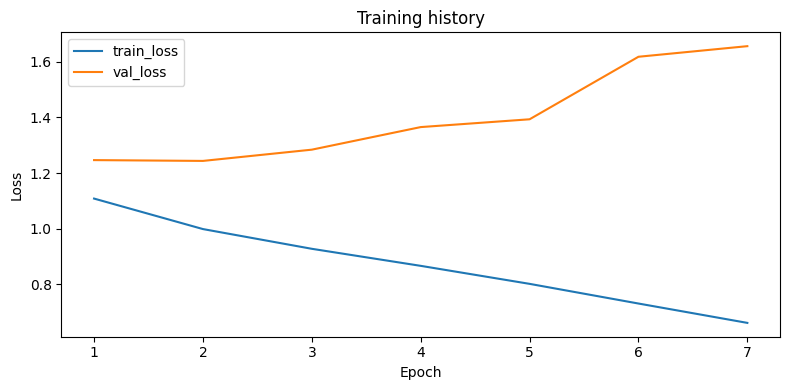

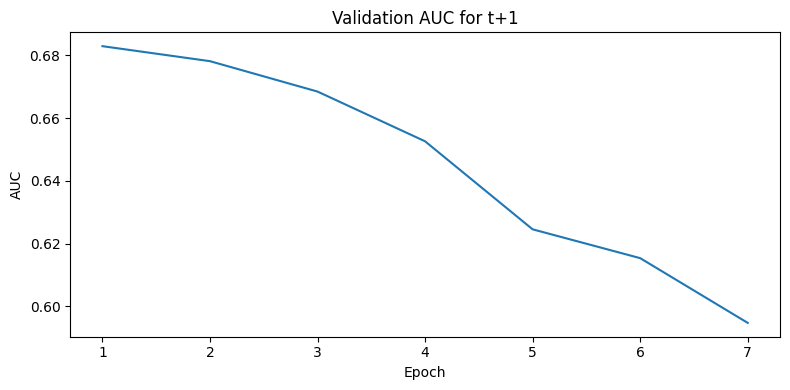

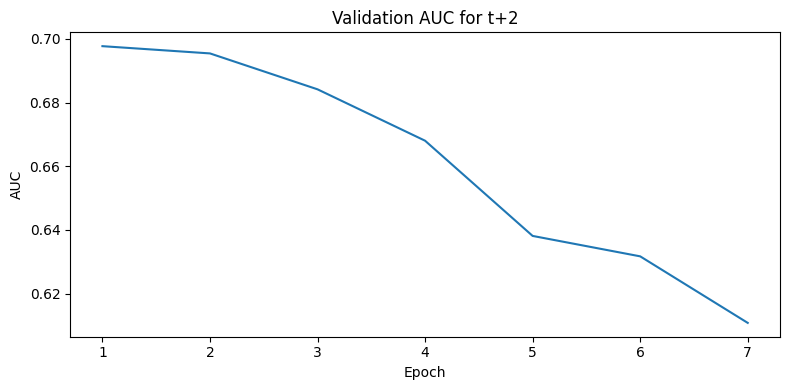

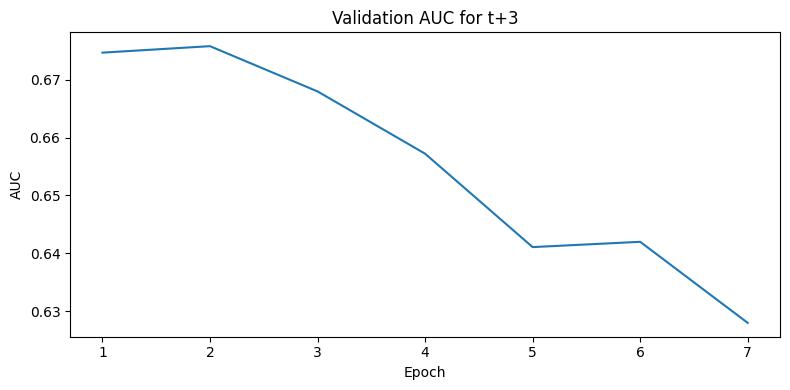

In [55]:

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_history_loss.png", dpi=300, bbox_inches="tight")
plt.show()

for h in range(1, HORIZON + 1):
    col = f"val_auc_t+{h}"
    if col in history_df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(history_df["epoch"], history_df[col])
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.title(f"Validation AUC for t+{h}")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"val_auc_tplus{h}.png", dpi=300, bbox_inches="tight")
        plt.show()

## 17. Evaluation on train / val / test

We score all samples and save the predictions.  
You get both:

- loss (same masked/weighted definition as in training)
- AUC per horizon
- average precision per horizon
- threshold-based metrics per horizon: sensitivity, specificity, precision, and recall
- a CSV with targets, masks, and probabilities

In [56]:

train_metrics, train_pred = evaluate_model(
    model, train_loader, DEVICE, threshold=EVAL_THRESHOLD, pos_weight=POS_WEIGHT_TENSOR
)
val_metrics, val_pred = evaluate_model(
    model, val_loader, DEVICE, threshold=EVAL_THRESHOLD, pos_weight=POS_WEIGHT_TENSOR
)
test_metrics, test_pred = evaluate_model(
    model, test_loader, DEVICE, threshold=EVAL_THRESHOLD, pos_weight=POS_WEIGHT_TENSOR
)

train_pred.to_csv(OUTPUT_DIR / "train_predictions.csv", index=False)
val_pred.to_csv(OUTPUT_DIR / "val_predictions.csv", index=False)
test_pred.to_csv(OUTPUT_DIR / "test_predictions_default_threshold.csv", index=False)

run_config = {
    "BATCH_SIZE": BATCH_SIZE,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "EVAL_THRESHOLD": EVAL_THRESHOLD,
    "HORIZON": HORIZON,
    "LOOKBACK": LOOKBACK,
    "MIN_HISTORY_VISITS": MIN_HISTORY_VISITS,
}

metrics_rows = []
for split_name, metrics in [("train", train_metrics), ("val", val_metrics), ("test", test_metrics)]:
    row = {
        "split": split_name,
        "threshold_source": "default_eval_threshold",
        **run_config,
        **metrics,
    }
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUTPUT_DIR / f"metrics_summary_default_{RUN_NAME}.csv", index=False)
display(metrics_df)


,split,threshold_source,BATCH_SIZE,HIDDEN_SIZE,NUM_LAYERS,DROPOUT,LR,WEIGHT_DECAY,EPOCHS,PATIENCE,...,threshold_t+3,f1_t+3,tp_t+3,tn_t+3,fp_t+3,fn_t+3,sensitivity_t+3,specificity_t+3,precision_t+3,recall_t+3
0,train,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.5,0.502222,113,676,152,72,0.610811,0.816425,0.426415,0.610811
1,val,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.5,0.458333,33,113,51,27,0.550000,0.689024,0.392857,0.550000
2,test,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.5,0.480620,31,155,51,16,0.659574,0.752427,0.378049,0.659574


In [57]:

# 17a. Bootstrap confidence intervals for test AUC
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

SEED = 42
N_BOOTSTRAP_SAMPLES = 1000

bootstrap_rows = []
rng = np.random.RandomState(SEED)

for h in range(1, HORIZON + 1):
    target_col = f"target_t+{h}"
    mask_col = f"mask_t+{h}"
    prob_col = f"prob_t+{h}"

    sub = test_pred[test_pred[mask_col] == 1].copy()
    y_true = sub[target_col].astype(int).to_numpy()
    y_prob = sub[prob_col].astype(float).to_numpy()

    if len(np.unique(y_true)) < 2:
        auc = np.nan
        ci_lo = np.nan
        ci_hi = np.nan
    else:
        auc = roc_auc_score(y_true, y_prob)

        boot_aucs = []
        for _ in range(N_BOOTSTRAP_SAMPLES):
            bs = resample(
                np.arange(len(y_true)),
                replace=True,
                n_samples=len(y_true),
                random_state=int(rng.randint(0, 2**31 - 1)),
            )
            y_bs = y_true[bs]
            p_bs = y_prob[bs]

            if len(np.unique(y_bs)) < 2:
                continue

            boot_aucs.append(roc_auc_score(y_bs, p_bs))

        if len(boot_aucs) == 0:
            ci_lo = np.nan
            ci_hi = np.nan
        else:
            ci_lo = float(np.percentile(boot_aucs, 2.5))
            ci_hi = float(np.percentile(boot_aucs, 97.5))

    print(f"t+{h}: AUC={auc:.3f}  95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]")

    bootstrap_rows.append({
        "horizon": f"t+{h}",
        "auc": auc,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
    })

bootstrap_ci_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci_df.to_csv(OUTPUT_DIR / f"bootstrap_ci_{RUN_NAME}.csv", index=False)
print("Saved:", OUTPUT_DIR / f"bootstrap_ci_{RUN_NAME}.csv")

# Merge bootstrap CI results into test row of metrics summary
test_metrics_with_ci = test_metrics.copy()
for h in range(1, HORIZON + 1):
    bs_row = bootstrap_ci_df[bootstrap_ci_df["horizon"] == f"t+{h}"].iloc[0]
    test_metrics_with_ci[f"ci_lo_t+{h}"] = bs_row["ci_lo"]
    test_metrics_with_ci[f"ci_hi_t+{h}"] = bs_row["ci_hi"]

print("Bootstrap CI columns merged into test_metrics_with_ci")


t+1: AUC=0.768  95% CI=[0.695, 0.835]
t+2: AUC=0.760  95% CI=[0.689, 0.826]
t+3: AUC=0.789  95% CI=[0.722, 0.849]
Saved: ../../Results/LSTM/feature_setB/results/top30_H3_L3_HS64_BS16_E55_P5_N1_D10/bootstrap_ci_top30_H3_L3_HS64_BS16_E55_P5_N1_D10.csv
Bootstrap CI columns merged into test_metrics_with_ci


In [58]:

## 17b. Find optimal threshold per horizon on the validation set

def find_best_threshold(pred_df, horizon):
    best_thresh = 0.5
    best_j = -1

    sub = pred_df[pred_df[f"mask_t+{horizon}"] == 1].copy()
    y_true = sub[f"target_t+{horizon}"].values
    y_prob = sub[f"prob_t+{horizon}"].values

    for thresh in np.arange(0.1, 0.9, 0.02):
        preds = (y_prob >= thresh).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        tn = ((preds == 0) & (y_true == 0)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        j = sens + spec - 1

        if j > best_j:
            best_j = j
            best_thresh = thresh

    return best_thresh, best_j

# Evaluate on the validation set and get pred_df
_, val_pred_df = evaluate_model(model, val_loader, DEVICE,
                                threshold=0.5, pos_weight=POS_WEIGHT_TENSOR)

BEST_THRESHOLDS = {}
for h in range(1, HORIZON + 1):
    thresh, j = find_best_threshold(val_pred_df, h)
    BEST_THRESHOLDS[h] = thresh
    print(f"t+{h}: best threshold = {thresh:.2f},  Youden J = {j:.3f}")

# Re-evaluate the test set using per-horizon optimal thresholds and save as primary summary output
test_metrics_opt, test_pred_opt = evaluate_model(
    model,
    test_loader,
    DEVICE,
    threshold=BEST_THRESHOLDS,
    pos_weight=POS_WEIGHT_TENSOR,
 )
test_pred_opt.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

run_config = {
    "BATCH_SIZE": BATCH_SIZE,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "EVAL_THRESHOLD": EVAL_THRESHOLD,
    "HORIZON": HORIZON,
    "LOOKBACK": LOOKBACK,
    "MIN_HISTORY_VISITS": MIN_HISTORY_VISITS,
}

metrics_rows = [
    {"split": "train", "threshold_source": "default_eval_threshold", **run_config, **train_metrics},
    {"split": "val", "threshold_source": "default_eval_threshold", **run_config, **val_metrics},
    {"split": "test", "threshold_source": "best_thresholds_from_val_youden_j", **run_config, **test_metrics_opt},
]
metrics_df_opt = pd.DataFrame(metrics_rows)

# Merge bootstrap CI into test row
for h in range(1, HORIZON + 1):
    bs_row = bootstrap_ci_df[bootstrap_ci_df["horizon"] == f"t+{h}"].iloc[0]
    metrics_df_opt.loc[metrics_df_opt["split"] == "test", f"ci_lo_t+{h}"] = bs_row["ci_lo"]
    metrics_df_opt.loc[metrics_df_opt["split"] == "test", f"ci_hi_t+{h}"] = bs_row["ci_hi"]

metrics_df_opt.to_csv(OUTPUT_DIR / f"metrics_summary_{RUN_NAME}.csv", index=False)

# Also merge bootstrap CI into the default threshold metrics (which was already saved earlier)
metrics_rows_default = [
    {"split": "train", "threshold_source": "default_eval_threshold", **run_config, **train_metrics},
    {"split": "val", "threshold_source": "default_eval_threshold", **run_config, **val_metrics},
    {"split": "test", "threshold_source": "default_eval_threshold", **run_config, **test_metrics},
]
metrics_df_default = pd.DataFrame(metrics_rows_default)

# Merge bootstrap CI into test row of default metrics as well
for h in range(1, HORIZON + 1):
    bs_row = bootstrap_ci_df[bootstrap_ci_df["horizon"] == f"t+{h}"].iloc[0]
    metrics_df_default.loc[metrics_df_default["split"] == "test", f"ci_lo_t+{h}"] = bs_row["ci_lo"]
    metrics_df_default.loc[metrics_df_default["split"] == "test", f"ci_hi_t+{h}"] = bs_row["ci_hi"]

metrics_df_default.to_csv(OUTPUT_DIR / f"metrics_summary_default_{RUN_NAME}.csv", index=False)

print(f"Saved: metrics_summary_{RUN_NAME}.csv (with optimized thresholds)")
print(f"Saved: metrics_summary_default_{RUN_NAME}.csv (with default threshold, updated with bootstrap CI)")
display(metrics_df_opt)


t+1: best threshold = 0.50,  Youden J = 0.333
t+2: best threshold = 0.46,  Youden J = 0.374
t+3: best threshold = 0.46,  Youden J = 0.298
Saved: metrics_summary_top30_H3_L3_HS64_BS16_E55_P5_N1_D10.csv (with optimized thresholds)
Saved: metrics_summary_default_top30_H3_L3_HS64_BS16_E55_P5_N1_D10.csv (with default threshold, updated with bootstrap CI)


,split,threshold_source,BATCH_SIZE,HIDDEN_SIZE,NUM_LAYERS,DROPOUT,LR,WEIGHT_DECAY,EPOCHS,PATIENCE,...,sensitivity_t+3,specificity_t+3,precision_t+3,recall_t+3,ci_lo_t+1,ci_hi_t+1,ci_lo_t+2,ci_hi_t+2,ci_lo_t+3,ci_hi_t+3
0,train,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.610811,0.816425,0.426415,0.610811,NaN,NaN,NaN,NaN,NaN,NaN
1,val,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.550000,0.689024,0.392857,0.550000,NaN,NaN,NaN,NaN,NaN,NaN
2,test,best_thresholds_from_val_youden_j,16,64,1,0.1,0.001,0.0001,55,5,...,0.765957,0.684466,0.356436,0.765957,0.694739,0.834876,0.689058,0.825975,0.721586,0.849423


## 18. Some quick plots of test predictions

These plots show the distribution of predicted probabilities for each future horizon.

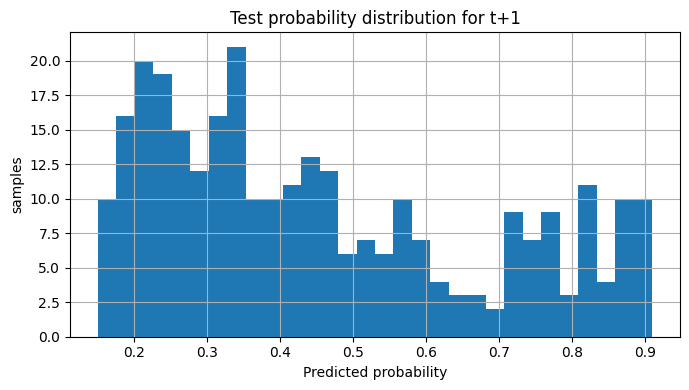

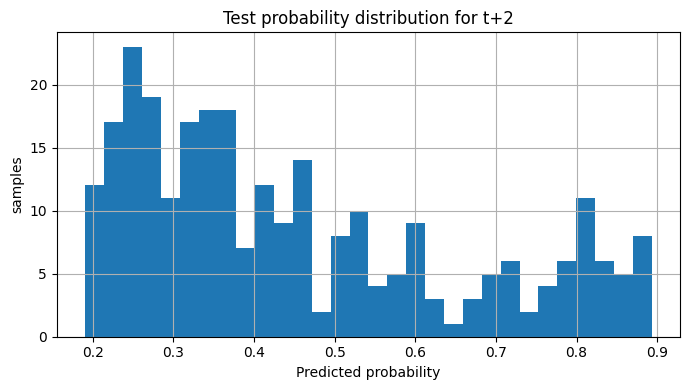

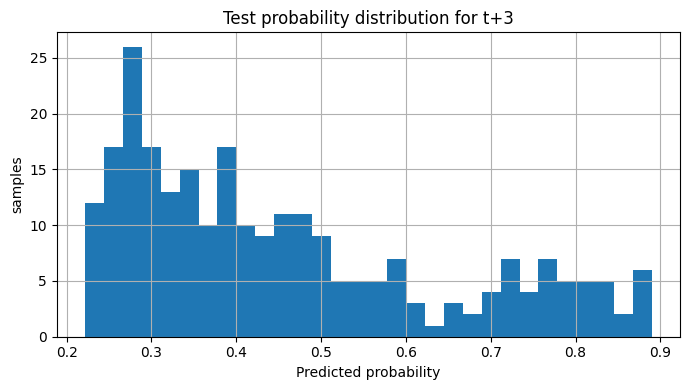

In [59]:

for h in range(1, HORIZON + 1):
    sub = test_pred[test_pred[f"mask_t+{h}"] == 1].copy()
    if len(sub) == 0:
        continue

    plt.figure(figsize=(7, 4))
    sub[f"prob_t+{h}"].hist(bins=30)
    plt.title(f"Test probability distribution for t+{h}")
    plt.xlabel("Predicted probability")
    plt.ylabel("samples")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"test_prob_dist_tplus{h}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 19. Example: threshold to 0/1

The model learns probabilities.  
If you want hard classifications, you can threshold them, for example at `0.5`.

You can later switch to a per-horizon threshold based on the validation set.

In [60]:


threshold_preview = test_pred.copy()
# Bruk per-horisont threshold fra val-settet
for h in range(1, HORIZON + 1):
    threshold_preview[f"pred_class_t+{h}"] = (
        threshold_preview[f"prob_t+{h}"] >= BEST_THRESHOLDS[h]
    ).astype(int)



threshold_preview.to_csv(OUTPUT_DIR / "test_predictions_thresholded.csv", index=False)
display(threshold_preview.head(10))

,patient_id,input_end_visit,target_t+1,mask_t+1,prob_t+1,target_t+2,mask_t+2,prob_t+2,target_t+3,mask_t+3,prob_t+3,pred_class_t+1,pred_class_t+2,pred_class_t+3
0,A01,6,0.0,1.0,0.345015,0.0,1.0,0.314824,0.0,1.0,0.366847,0,0,0
1,A01,7,0.0,1.0,0.352572,0.0,1.0,0.336104,0.0,1.0,0.365436,0,0,0
2,A01,8,0.0,1.0,0.399742,0.0,1.0,0.415228,0.0,1.0,0.427911,0,0,0
3,A01,9,0.0,1.0,0.570594,0.0,1.0,0.515008,1.0,1.0,0.505623,1,1,1
4,A01,10,0.0,1.0,0.575722,1.0,1.0,0.530625,0.0,1.0,0.508304,1,1,1
5,A01,11,1.0,1.0,0.448876,0.0,1.0,0.384741,0.0,1.0,0.391749,0,0,0
6,A01,13,0.0,1.0,0.443040,0.0,1.0,0.411210,0.0,1.0,0.397986,0,0,0
7,A01,14,0.0,1.0,0.516780,0.0,1.0,0.483227,0.0,1.0,0.454807,1,1,0
8,A01,15,0.0,1.0,0.438110,0.0,1.0,0.386328,0.0,1.0,0.388364,0,0,0
9,A01,16,0.0,1.0,0.418408,0.0,1.0,0.396388,0.0,1.0,0.391120,0,0,0


In [61]:
# Patients contributing at least one sample
train_pids = set(s["patient_id"] for s in train_samples)
val_pids   = set(s["patient_id"] for s in val_samples)
test_pids  = set(s["patient_id"] for s in test_samples)

print(f"Pasienter med samples — train: {len(train_pids)}, val: {len(val_pids)}, test: {len(test_pids)}")
print(f"Train-pasienter uten samples: {len(set(train_ids) - train_pids)}")
print(f"Val-pasienter uten samples:   {len(set(val_ids) - val_pids)}")
print(f"Test-pasienter uten samples:  {len(set(test_ids) - test_pids)}")

Pasienter med samples — train: 126, val: 26, test: 29
Train-pasienter uten samples: 22
Val-pasienter uten samples:   6
Test-pasienter uten samples:  3


## 20. Next steps

Natural next steps after this baseline runs:

1. expand the feature set gradually
2. tune `LOOKBACK` (e.g., 3, 4, 5) and `MIN_HISTORY_VISITS`
3. compare `HORIZON=1`, `HORIZON=3`, and `HORIZON=5`
4. tune the threshold per horizon on the validation set
5. try a simple hyperparameter search for `hidden_size`, `num_layers`, `dropout`
6. create patient-level summaries in addition to sample-level metrics

This notebook is meant to be a clean and safe starting point without leakage.